#### Series de tiempo 

Las series de tiempo tienen una variable númmerica las cuales dependen del tiempo, queremos poder identificar:  
Cambios sostenidos en el tiempo como las tendencias, tendencias aritméticas (lineales) y geométricas (exponenciales)  
Patrones ciclicos en apmlitud, osea el comportamiento de la Y   
Patrones ciclicos de frecuencia, valores o secuencias que se repiten enel tiempo   

Los modelos de series de tiempo se intentan representar de esta manera

Yt ~ Yt-n (La Y actual depende de una y )

Entraremos en la familia de modelos Sarimax, la cual es la más compleja, existen los modelos de suavización exponencial, estos modelos dicen que toda la información pasada existe en el paso anterior o y anterior, pero las Sarimax añaden complejidad y identifican una ventana de eventos del pasado la cual es usada para encontrar la Y actual  

S: (stationary): 
- Me interesa conocer los patrones de frecuencia y amplitud que se repiten en el tiempo  

AR: (Autoregressive): 
- Identifica que mis valores futuros dependen linealmente de una ventana del pasado (día a  día)  

I: (Integral) 
- La serie de tiempo es estacionaria la varianza (la amplitud entre los mismos valores),covarianza (patrón repetitivo entre el mismo rango) y la media constante todo el tiempo (no cambia mientras avanza la serie) 

MA: Movile average
-  Los valores futuros de la serie dependen de los residuos de la ventana temporal en el pasado 

X: Exogeno
- Hay variables externas las cuales pueden afectar el comportamiento o tienen una variable que la impacta directamente Exogena/Endogena

Uno quisiera que después de quitar el modelo en la serie quedara solo ruido blanco: media 0 varianza 1 

Estos modelos incluyen todas estas caracteristicas

Los modelos sarimax se pueden calificar de don maneras, exaustiva o Box Jenkins

Parametros: SARIMAX(p,d,q)(P,D,Q)M   

p: cantidad de ventanas de la parte autoregresiva  p=3 significa que los utlimos 3 valores afectan el valor actual  
d: cantidad de veces que se transformó la serie para ser estacionaria, las acciones que se hacen sobre la serie  
q: tamaño de la ventana del proceso de media móvil, cuantos elementos residuales se toman para el proceso de media móvil  
P: Lo mismo de p pero estacional  
D: Lo mismo de d pero estacional  
Q: Lo mismo de q pero estacional  
M cada cuantos periodos se repite   

Estos párametros se encuentran 

ARMA: (2,3): modelo lineal  

1. Para identifica p,d,q:  
d: transformaciones a la estacionariedad   
- Test de Dickey-Fuller  VER EN NOTION
H0: la serie no es estacionaria   
H1: La serie es estacionaria   
- Si el estadistico es negativo y p < 0.05 se rechaza H0 la serie es estacionaria  
Para eliminar una __ se le resta los residuos, restar los residuales geométricos o aritméticos

p,q: verificamos autocorrelación (q) y autocorrelación parcial  (p)
- autocorelacion: que tanto influye un residual pasado al comportamiento actual  
Se saca el gráfico de autocorrelación {-1, 1} q es la cantidad secuencial de resagos que se salgan de las bandas de aceptación de la gráfica  
La relación con todos los anteriores d ela Y actual  
- autocorrelación parcial: que tanto los eventos pasados no secuenciales aportan al comportamiento actual  
Mismo gráfico y mismas condiciones  
La relación de cada una de las Y con la anterior por eso se llama parcial  

2. Estimar los coeficientes de los ARMA  
Criterios de máxima verisimilitud  
Minimizar el critério de Alcaique: -2 * log(verosim) + 2* Qparámetros


#### 1. Entendimiento del problema
El gobierno autraliano quiere conocer el costo futuro de corticoides  y esteroides en el sistema de finanzas actual  
#### 2. Enfoque analítico
Contruiremos un modelo de series de tiempo que permita estimar este costo con el menor MAE posible 
#### 3. Requerimiento de los datos 
Datos pasados de los medicamentos
#### 4. Recolección de datos


In [11]:
import numpy as np 
import pandas as pd 
import seaborn as sb 
import matplotlib.pyplot as plt
from skforecast.datasets import fetch_dataset

In [8]:
data = fetch_dataset(name = 'h2o_exog')
data.index.name = 'datetime'

╭─────────────────────────────────── h2o_exog ────────────────────────────────────╮
│ Description:                                                                    │
│ Monthly expenditure ($AUD) on corticosteroid drugs that the Australian health   │
│ system had between 1991 and 2008. Two additional variables (exog_1, exog_2) are │
│ simulated.                                                                      │
│                                                                                 │
│ Source:                                                                         │
│ Hyndman R (2023). fpp3: Data for Forecasting: Principles and Practice (3rd      │
│ Edition). http://pkg.robjhyndman.com/fpp3package/,                              │
│ https://github.com/robjhyndman/fpp3package, http://OTexts.com/fpp3.             │
│                                                                                 │
│ URL:                                                                            │
│ https://raw.githubusercontent.com/skforecast/skforecast-                        │
│ datasets/main/data/h2o_exog.csv                                                 │
│                                                                                 │
│ Shape: 195 rows x 3 columns                                                     │
╰─────────────────────────────────────────────────────────────────────────────────╯

In [9]:
data

,y,exog_1,exog_2
datetime,,,
1992-04-01,0.379808,0.958792,1.166029
1992-05-01,0.361801,0.951993,1.117859
1992-06-01,0.410534,0.952955,1.067942
1992-07-01,0.483389,0.958078,1.097376
1992-08-01,0.475463,0.956370,1.122199
...,...,...,...
2008-02-01,0.761822,1.515840,1.786373
2008-03-01,0.649435,1.506258,1.694264
2008-04-01,0.827887,1.505253,1.627135


#### 5. Exploración de los datos
- Identificar los patrones estacionales de la serie 
- Determinar a estacioneridad de la serie 

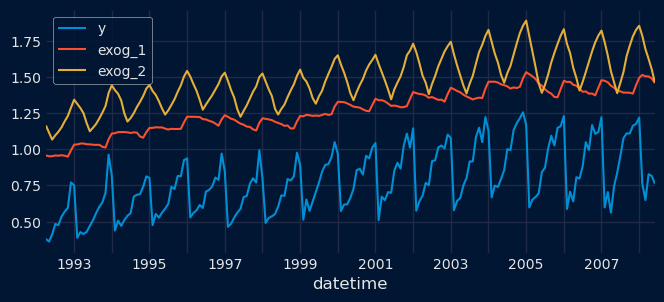

In [12]:
from skforecast.plot import set_dark_theme
set_dark_theme()
fig, ax = plt.subplots(figsize=(7,3))
data.plot(ax=ax)
ax.legend()
plt.show()

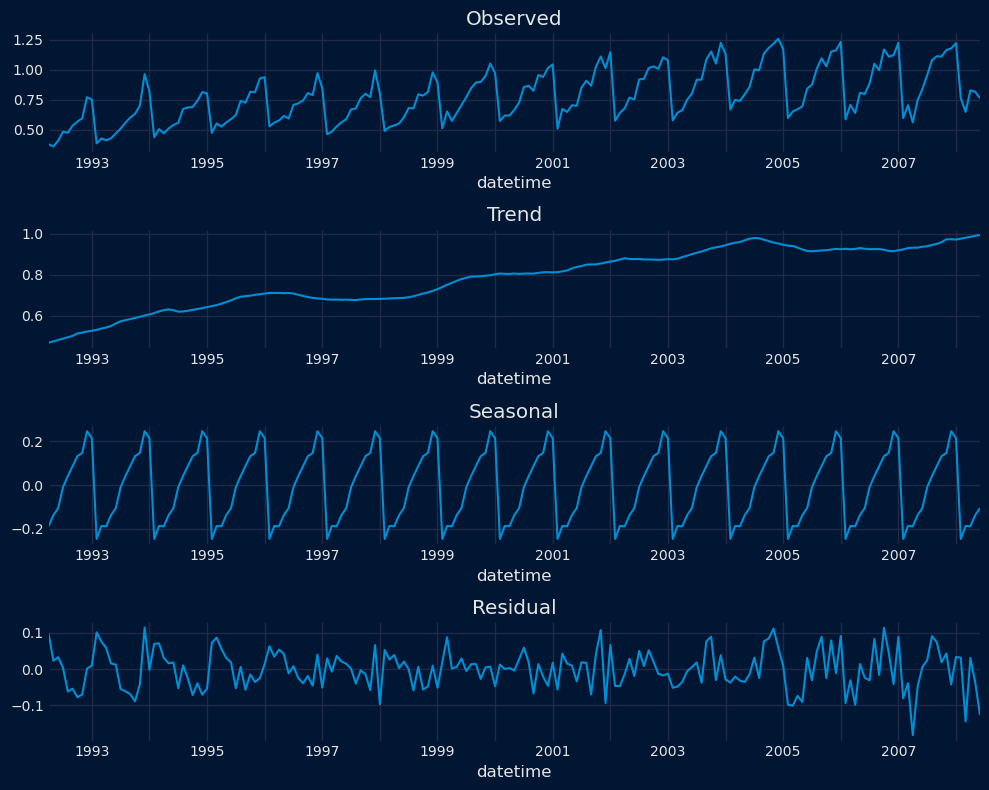

In [13]:
from statsmodels.tsa.seasonal import seasonal_decompose

# ya que la tendencia es lineal creciente ponemos additivo multiplicativo es el exponencial
result = seasonal_decompose(data['y'], model='additive', extrapolate_trend= 'freq') 
fig, ax = plt.subplots(4,1 , figsize=(10,8))
result.observed.plot(ax=ax[0], legend=False)
ax[0].set_title('Observed')
result.trend.plot(ax=ax[1], legend=False)
ax[1].set_title('Trend')
result.seasonal.plot(ax=ax[2], legend=False)
ax[2].set_title('Seasonal')
result.resid.plot(ax=ax[3], legend=False)
ax[3].set_title('Residual')
plt.tight_layout()
plt.show()


Vemos que hay una repetición cada 12 periodos, cada 12 meses se repite el ciclo dentro del mismo rango  
Cuando el residual no es blanco, significa que los valores exogenos tienen un comportamiento atipico  

In [15]:
from statsmodels.tsa.stattools import adfuller
print('test de adfuller')
ad_result = adfuller(data['y'])
print(f'statistic: {ad_result[0]}')
print(f'p-value: {ad_result[1]}')

test de adfuller
statistic: -1.518045806093375
p-value: 0.5245662008648517


El estadistico es negativo pero el p es mayor a 0,5 entonces se acepta H0 la serie no es estacional  
#### Preparación de los datos 

En este caso necesitamos quitarle la tendencia a la serie ya que cumple con la condición de varianza y covarianza  
- Diferenciar la serie  
- Identificar su comportamiento estacional  


test de estacionaridad
statistic: -3.272501193023043
p-value: 0.01615332013566986


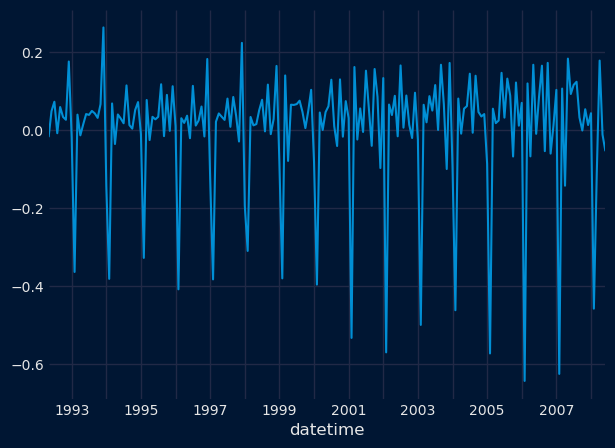

In [16]:
data_diff = data['y'].diff().dropna()

print('test de estacionaridad')
adfuller_result = adfuller(data_diff)
print(f'statistic: {adfuller_result[0]}')
print(f'p-value: {adfuller_result[1]}')
data_diff.plot()
plt.show()

Cada que diferenciamos perdemos información, pero esta serie ya cumple con los requerimientos del test de adfuller, también podríamos aplicar log


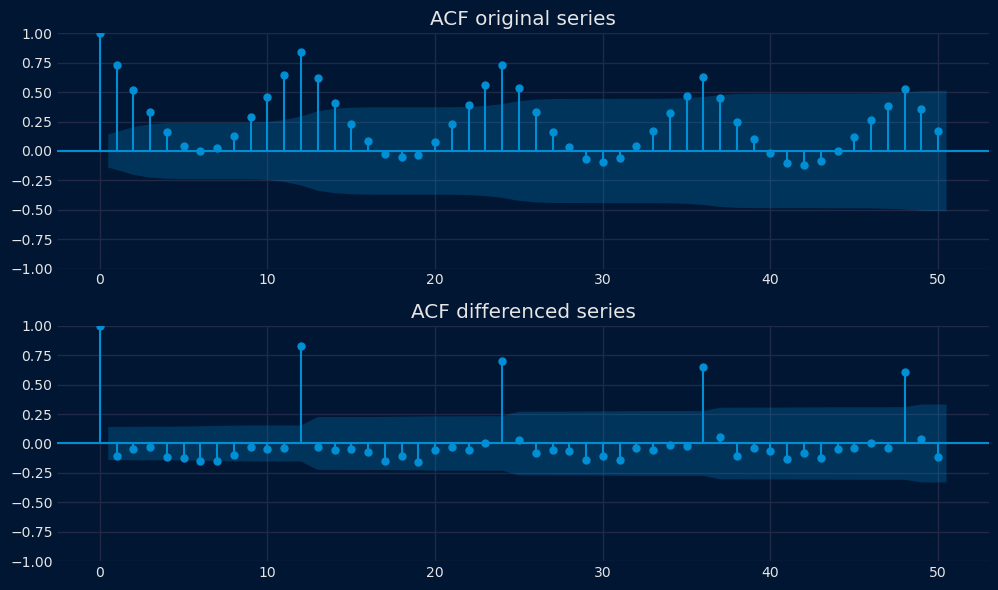

In [17]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(2,1, figsize=(10,6))
plot_acf(data['y'], lags=50, ax=ax[0], alpha=0.05)
ax[0].set_title('ACF original series')
plot_acf(data_diff, lags=50, ax=ax[1], alpha=0.05)
ax[1].set_title('ACF differenced series')
plt.tight_layout()
plt.show()

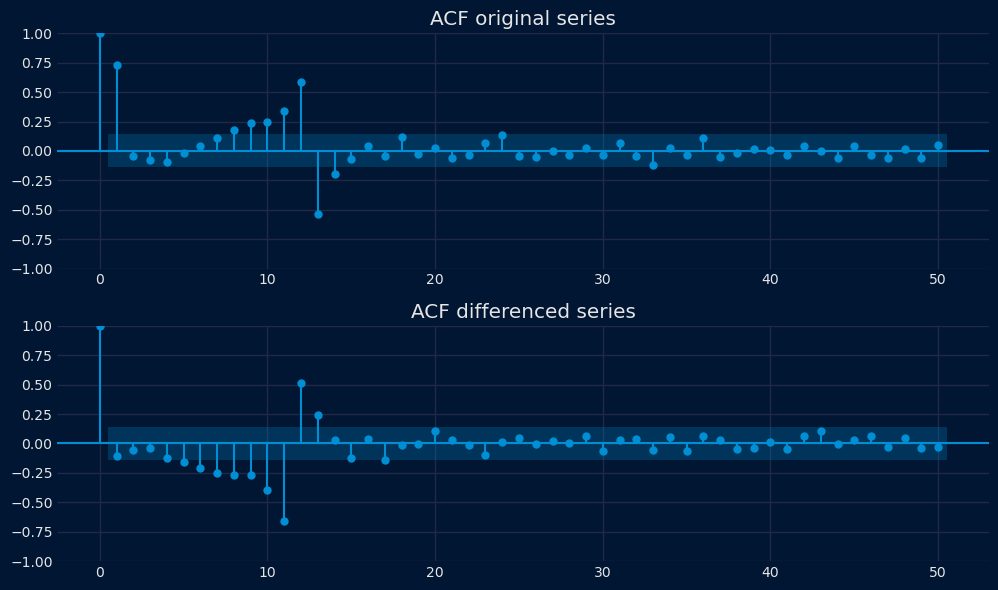

In [18]:
fig, ax = plt.subplots(2,1, figsize=(10,6))
plot_pacf(data['y'], lags=50, ax=ax[0], alpha=0.05)
ax[0].set_title('ACF original series')
plot_pacf(data_diff, lags=50, ax=ax[1], alpha=0.05)
ax[1].set_title('ACF differenced series')
plt.tight_layout()
plt.show()